In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Optional: Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("/content/dataset.csv.zip")

In [ ]:
df

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,posting_date,document_create_date,document_create_date.1,due_in_date,invoice_currency,document type,posting_id,area_business,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen
0,U001,0200769623,WAL-MAR corp,2020-02-11 00:00:00,2020.0,1.930438e+09,2020-01-26,20200125,20200126,20200210.0,USD,RV,1.0,NaN,54273.28,20200126.0,NAH4,1.930438e+09,0
1,U001,0200980828,BEN E,2019-08-08 00:00:00,2019.0,1.929646e+09,2019-07-22,20190722,20190722,20190811.0,USD,RV,1.0,NaN,79656.60,20190722.0,NAD1,1.929646e+09,0
2,U001,0200792734,MDV/ trust,2019-12-30 00:00:00,2019.0,1.929874e+09,2019-09-14,20190914,20190914,20190929.0,USD,RV,1.0,NaN,2253.86,20190914.0,NAA8,1.929874e+09,0
3,CA02,0140105686,SYSC llc,NaN,2020.0,2.960623e+09,2020-03-30,20200330,20200330,20200410.0,CAD,RV,1.0,NaN,3299.70,20200331.0,CA10,2.960623e+09,1
4,U001,0200769623,WAL-MAR foundation,2019-11-25 00:00:00,2019.0,1.930148e+09,2019-11-13,20191113,20191113,20191128.0,USD,RV,1.0,NaN,33133.29,20191113.0,NAH4,1.930148e+09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U001,0200561861,CO corporation,NaN,2020.0,1.930797e+09,2020-04-21,20200417,20200421,20200506.0,USD,RV,1.0,NaN,3187.86,20200421.0,NAA8,1.930797e+09,1
49996,U001,0200769623,WAL-MAR co,2019-09-03 00:00:00,2019.0,1.929744e+09,2019-08-15,20190814,20190815,20190830.0,USD,RV,1.0,NaN,6766.54,20190815.0,NAH4,1.929744e+09,0
49997,U001,0200772595,SAFEW associates,2020-03-05 00:00:00,2020.0,1.930537e+09,2020-02-19,20200218,20200219,20200305.0,USD,RV,1.0,NaN,6120.86,20200219.0,NAA8,1.930537e+09,0
49998,U001,0200726979,BJ'S llc,2019-12-12 00:00:00,2019.0,1.930199e+09,2019-11-27,20191126,20191127,20191212.0,USD,RV,1.0,NaN,63.48,20191127.0,NAA8,1.930199e+09,0


In [ ]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           50000 non-null  object 
 1   cust_number             50000 non-null  object 
 2   name_customer           50000 non-null  object 
 3   clear_date              40000 non-null  object 
 4   buisness_year           50000 non-null  float64
 5   doc_id                  50000 non-null  float64
 6   posting_date            50000 non-null  object 
 7   document_create_date    50000 non-null  int64  
 8   document_create_date.1  50000 non-null  int64  
 9   due_in_date             50000 non-null  float64
 10  invoice_currency        50000 non-null  object 
 11  document type           50000 non-null  object 
 12  posting_id              50000 non-null  float64
 13  area_business           0 non-null      float64
 14  total_open_amount       50000 non-null

,buisness_year,doc_id,document_create_date,document_create_date.1,due_in_date,posting_id,area_business,total_open_amount,baseline_create_date,invoice_id,isOpen
count,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.0,0.0,50000.000000,5.000000e+04,4.999400e+04,50000.000000
mean,2019.305700,2.012238e+09,2.019351e+07,2.019354e+07,2.019368e+07,1.0,NaN,32337.021651,2.019354e+07,2.011340e+09,0.200000
std,0.460708,2.885235e+08,4.496041e+03,4.482134e+03,4.470614e+03,0.0,NaN,39205.975231,4.482701e+03,2.766335e+08,0.400004
min,2019.000000,1.928502e+09,2.018123e+07,2.018123e+07,2.018122e+07,1.0,NaN,0.720000,2.018121e+07,1.928502e+09,0.000000
25%,2019.000000,1.929342e+09,2.019050e+07,2.019051e+07,2.019052e+07,1.0,NaN,4928.312500,2.019050e+07,1.929342e+09,0.000000
50%,2019.000000,1.929964e+09,2.019091e+07,2.019091e+07,2.019093e+07,1.0,NaN,17609.010000,2.019091e+07,1.929964e+09,0.000000
75%,2020.000000,1.930619e+09,2.020013e+07,2.020013e+07,2.020022e+07,1.0,NaN,47133.635000,2.020013e+07,1.930619e+09,0.000000
max,2020.000000,9.500000e+09,2.020052e+07,2.020052e+07,2.020071e+07,1.0,NaN,668593.360000,2.020052e+07,2.960636e+09,1.000000


In [ ]:
relevant_columns = [
    'business_code',
    'cust_number',
    'clear_date',
    'buisness_year',
    'posting_date',
    'document_create_date',     # corrected
    'due_in_date',
    'document type',            # corrected
    'total_open_amount',
    'baseline_create_date',
    'cust_payment_terms'
]
df = df[relevant_columns]

In [ ]:
df

,business_code,cust_number,clear_date,buisness_year,posting_date,document_create_date,due_in_date,document type,total_open_amount,baseline_create_date,cust_payment_terms
0,U001,0200769623,2020-02-11 00:00:00,2020.0,2020-01-26,20200125,20200210.0,RV,54273.28,20200126.0,NAH4
1,U001,0200980828,2019-08-08 00:00:00,2019.0,2019-07-22,20190722,20190811.0,RV,79656.60,20190722.0,NAD1
2,U001,0200792734,2019-12-30 00:00:00,2019.0,2019-09-14,20190914,20190929.0,RV,2253.86,20190914.0,NAA8
3,CA02,0140105686,NaN,2020.0,2020-03-30,20200330,20200410.0,RV,3299.70,20200331.0,CA10
4,U001,0200769623,2019-11-25 00:00:00,2019.0,2019-11-13,20191113,20191128.0,RV,33133.29,20191113.0,NAH4
...,...,...,...,...,...,...,...,...,...,...,...
49995,U001,0200561861,NaN,2020.0,2020-04-21,20200417,20200506.0,RV,3187.86,20200421.0,NAA8
49996,U001,0200769623,2019-09-03 00:00:00,2019.0,2019-08-15,20190814,20190830.0,RV,6766.54,20190815.0,NAH4
49997,U001,0200772595,2020-03-05 00:00:00,2020.0,2020-02-19,20200218,20200305.0,RV,6120.86,20200219.0,NAA8
49998,U001,0200726979,2019-12-12 00:00:00,2019.0,2019-11-27,20191126,20191212.0,RV,63.48,20191127.0,NAA8


In [ ]:
df.shape

(50000, 11)

In [ ]:
# Convert date columns to datetime
df['clear_date'] = pd.to_datetime(df['clear_date'], errors='coerce')
df['due_in_date'] = pd.to_datetime(df['due_in_date'], format='%Y%m%d', errors='coerce')
df['document_create_date'] = pd.to_datetime(df['document_create_date'], format='%Y%m%d', errors='coerce')
# Create binary target: 1 if late, 0 if on time or early
df['is_late'] = (df['clear_date'] > df['due_in_date']).astype(int)

In [ ]:
df[['clear_date', 'due_in_date', 'is_late']].head()

,clear_date,due_in_date,is_late
0,2020-02-11,2020-02-10,1
1,2019-08-08,2019-08-11,0
2,2019-12-30,2019-09-29,1
3,NaT,2020-04-10,0
4,2019-11-25,2019-11-28,0


In [ ]:
df.isnull().sum()

,0
business_code,0
cust_number,0
clear_date,10000
buisness_year,0
posting_date,0
document_create_date,0
due_in_date,0
document type,0
total_open_amount,0
baseline_create_date,0


In [ ]:
# Drop rows where clear_date is NaT (i.e., not paid yet)
df = df[df['clear_date'].notna()].copy()

# Check shape and nulls after dropping
print(df.shape)
print(df.isnull().sum())

(40000, 12)
business_code           0
cust_number             0
clear_date              0
buisness_year           0
posting_date            0
document_create_date    0
due_in_date             0
document type           0
total_open_amount       0
baseline_create_date    0
cust_payment_terms      0
is_late                 0
dtype: int64


In [ ]:
df.isnull().sum()

,0
business_code,0
cust_number,0
clear_date,0
buisness_year,0
posting_date,0
document_create_date,0
due_in_date,0
document type,0
total_open_amount,0
baseline_create_date,0


<Axes: xlabel='is_late'>

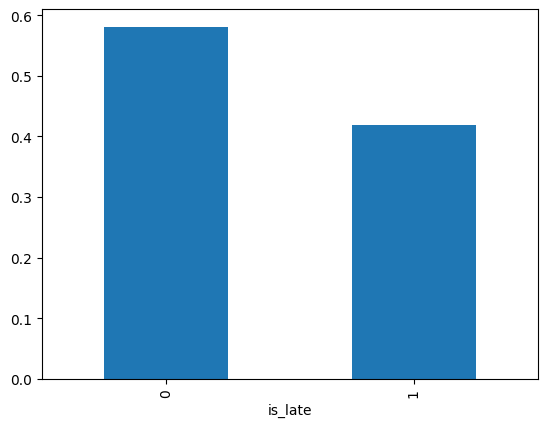

In [ ]:
df['is_late'].value_counts(normalize=True).plot(kind='bar')

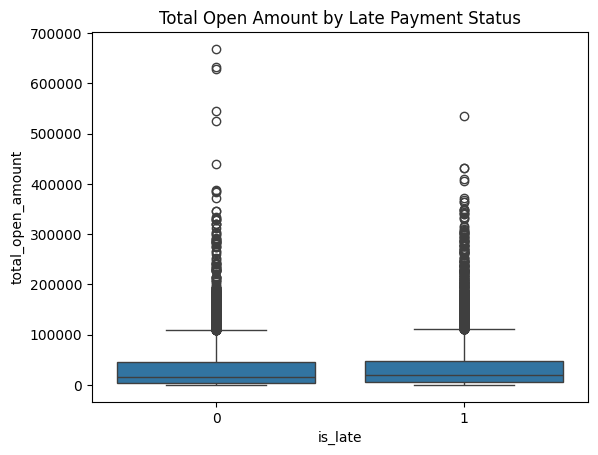

In [ ]:
sns.boxplot(x='is_late', y='total_open_amount', data=df)
plt.title("Total Open Amount by Late Payment Status")
plt.show()

In [ ]:
df

,business_code,cust_number,clear_date,buisness_year,posting_date,document_create_date,due_in_date,document type,total_open_amount,baseline_create_date,cust_payment_terms,is_late
0,U001,0200769623,2020-02-11,2020.0,2020-01-26,2020-01-25,2020-02-10,RV,54273.28,20200126.0,NAH4,1
1,U001,0200980828,2019-08-08,2019.0,2019-07-22,2019-07-22,2019-08-11,RV,79656.60,20190722.0,NAD1,0
2,U001,0200792734,2019-12-30,2019.0,2019-09-14,2019-09-14,2019-09-29,RV,2253.86,20190914.0,NAA8,1
4,U001,0200769623,2019-11-25,2019.0,2019-11-13,2019-11-13,2019-11-28,RV,33133.29,20191113.0,NAH4,0
5,CA02,0140106181,2019-12-04,2019.0,2019-09-20,2019-09-20,2019-10-04,RV,22225.84,20190924.0,CA10,1
...,...,...,...,...,...,...,...,...,...,...,...,...
49994,U001,0200762301,2019-07-25,2019.0,2019-07-10,2019-07-09,2019-07-25,RV,84780.40,20190710.0,NAC6,0
49996,U001,0200769623,2019-09-03,2019.0,2019-08-15,2019-08-14,2019-08-30,RV,6766.54,20190815.0,NAH4,1
49997,U001,0200772595,2020-03-05,2020.0,2020-02-19,2020-02-18,2020-03-05,RV,6120.86,20200219.0,NAA8,0
49998,U001,0200726979,2019-12-12,2019.0,2019-11-27,2019-11-26,2019-12-12,RV,63.48,20191127.0,NAA8,0


In [ ]:
print(df['baseline_create_date'].head(20))
print(df['baseline_create_date'].dtype)

0     20200126.0
1     20190722.0
2     20190914.0
4     20191113.0
5     20190924.0
6     20191101.0
8     20190607.0
9     20190220.0
11    20190102.0
12    20190415.0
13    20191017.0
16    20191025.0
17    20191202.0
18    20191115.0
19    20200124.0
20    20200111.0
21    20190821.0
23    20190717.0
24    20200124.0
26    20190114.0
Name: baseline_create_date, dtype: float64
float64


In [ ]:
# Step 1: Convert float to int (drop the decimal)
df['baseline_create_date'] = df['baseline_create_date'].astype('int64')

# Step 2: Convert to datetime using the correct format
df['baseline_create_date'] = pd.to_datetime(df['baseline_create_date'], format='%Y%m%d')

In [ ]:
print(df['baseline_create_date'].head())
print(df['baseline_create_date'].dtype)

0   2020-01-26
1   2019-07-22
2   2019-09-14
4   2019-11-13
5   2019-09-24
Name: baseline_create_date, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
df

,business_code,cust_number,clear_date,buisness_year,posting_date,document_create_date,due_in_date,document type,total_open_amount,baseline_create_date,cust_payment_terms,is_late
0,U001,0200769623,2020-02-11,2020.0,2020-01-26,2020-01-25,2020-02-10,RV,54273.28,2020-01-26,NAH4,1
1,U001,0200980828,2019-08-08,2019.0,2019-07-22,2019-07-22,2019-08-11,RV,79656.60,2019-07-22,NAD1,0
2,U001,0200792734,2019-12-30,2019.0,2019-09-14,2019-09-14,2019-09-29,RV,2253.86,2019-09-14,NAA8,1
4,U001,0200769623,2019-11-25,2019.0,2019-11-13,2019-11-13,2019-11-28,RV,33133.29,2019-11-13,NAH4,0
5,CA02,0140106181,2019-12-04,2019.0,2019-09-20,2019-09-20,2019-10-04,RV,22225.84,2019-09-24,CA10,1
...,...,...,...,...,...,...,...,...,...,...,...,...
49994,U001,0200762301,2019-07-25,2019.0,2019-07-10,2019-07-09,2019-07-25,RV,84780.40,2019-07-10,NAC6,0
49996,U001,0200769623,2019-09-03,2019.0,2019-08-15,2019-08-14,2019-08-30,RV,6766.54,2019-08-15,NAH4,1
49997,U001,0200772595,2020-03-05,2020.0,2020-02-19,2020-02-18,2020-03-05,RV,6120.86,2020-02-19,NAA8,0
49998,U001,0200726979,2019-12-12,2019.0,2019-11-27,2019-11-26,2019-12-12,RV,63.48,2019-11-27,NAA8,0


In [ ]:
df.isnull().sum()

,0
business_code,0
cust_number,0
clear_date,0
buisness_year,0
posting_date,0
document_create_date,0
due_in_date,0
document type,0
total_open_amount,0
baseline_create_date,0


In [ ]:
df['cust_payment_terms'].value_counts()

,count
cust_payment_terms,
NAA8,16016
NAH4,10593
CA10,3075
NAC6,1317
NAM4,1112
...,...
NATU,1
NAUW,1
CA60,1


In [ ]:
df['cust_payment_terms'].unique()

array(['NAH4', 'NAD1', 'NAA8', 'CA10', 'NAC6', 'NAAX', 'NAVE', 'NAG2',
       'NABG', 'NAM2', 'NA10', 'NAU5', 'NAD5', 'NAM4', 'NAWP', 'NAGD',
       'NAVR', 'CA30', 'NAM1', 'NAAW', 'NAVF', 'NAD4', 'NAUZ', 'NA3F',
       'NAX2', 'NAVQ', 'NATM', 'NA32', 'NAWM', 'NACB', 'NA38', 'NAWN',
       'NA84', 'C106', 'NAWU', 'NAB1', 'NA3B', 'NA9X', 'NAVD', 'CAB1',
       'NAVM', 'NA25', 'NAUP', 'NAM3', 'CAX2', 'NATV', 'NAVL', 'NATZ',
       'BR56', 'NA31', 'NATW', 'B052', 'NAV2', 'NATX', 'NAUY', 'NA8Q',
       'NATJ', 'BR12', 'NATU', '90M7', 'NAV9', 'NATK', 'CA60', 'NATL',
       'NAUW', 'NAVC', 'NABD', 'NATH', 'MC15', 'NAD8'], dtype=object)

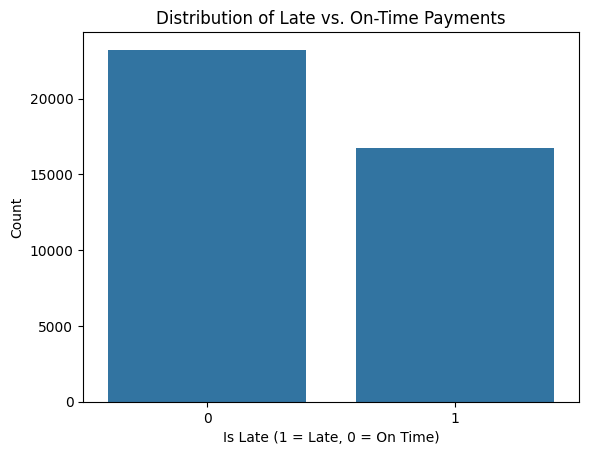

In [ ]:
sns.countplot(data=df, x='is_late')
plt.title("Distribution of Late vs. On-Time Payments")
plt.xlabel("Is Late (1 = Late, 0 = On Time)")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='is_late', ylabel='total_open_amount'>

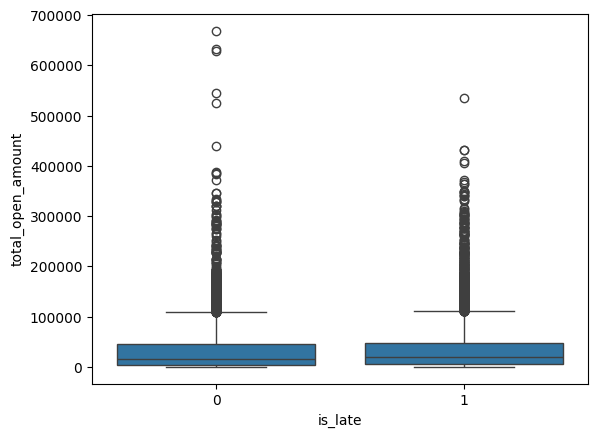

In [ ]:
sns.boxplot(data=df, x='is_late', y='total_open_amount')

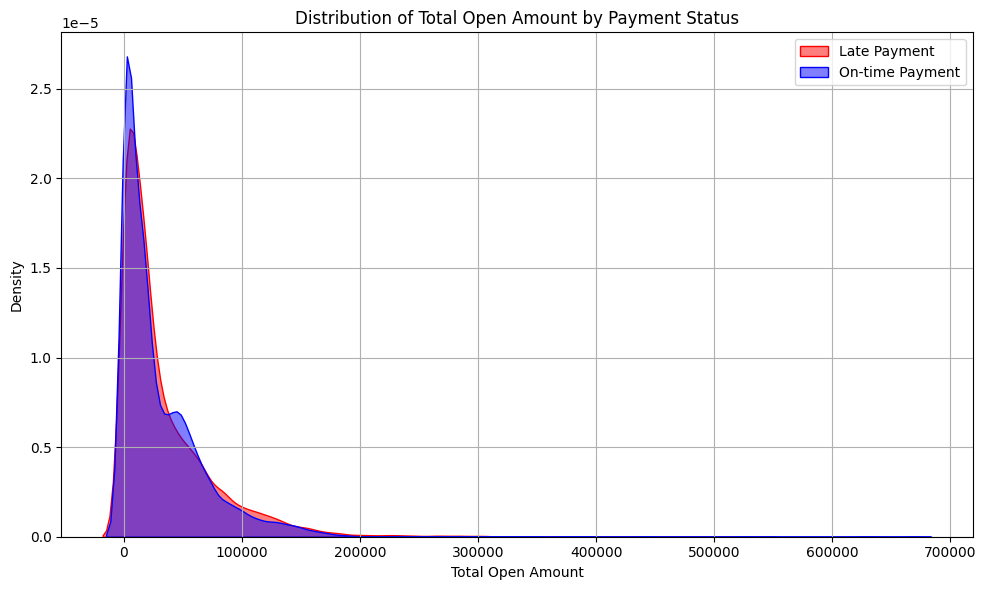

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(10, 6))

# Distribution for late payments (is_late == 1)
sns.kdeplot(data=df[df['is_late'] == 1], x='total_open_amount', label='Late Payment', fill=True, color='red', alpha=0.5)

# Distribution for on-time payments (is_late == 0)
sns.kdeplot(data=df[df['is_late'] == 0], x='total_open_amount', label='On-time Payment', fill=True, color='blue', alpha=0.5)

# Plot labels and legend
plt.title('Distribution of Total Open Amount by Payment Status')
plt.xlabel('Total Open Amount')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: xlabel='delay_days', ylabel='Count'>

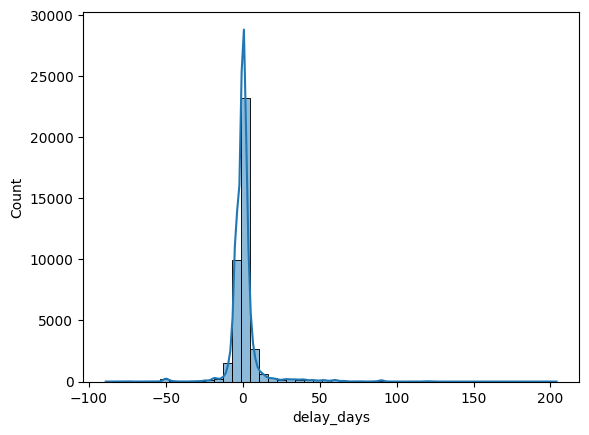

In [ ]:
df['delay_days'] = (df['clear_date'] - df['due_in_date']).dt.days
sns.histplot(data=df, x='delay_days', bins=50, kde=True)

<Axes: xlabel='delay_days', ylabel='Count'>

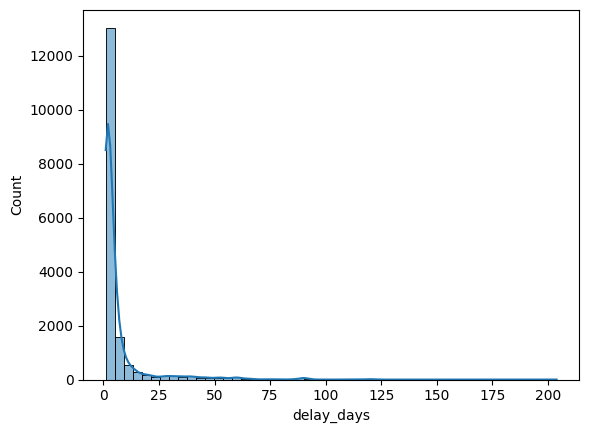

In [ ]:
sns.histplot(data=df[df['delay_days'] > 0], x='delay_days', bins=50, kde=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69],
 [Text(0, 0, 'NAH4'),
  Text(1, 0, 'NAD1'),
  Text(2, 0, 'NAA8'),
  Text(3, 0, 'CA10'),
  Text(4, 0, 'NAC6'),
  Text(5, 0, 'NAAX'),
  Text(6, 0, 'NAVE'),
  Text(7, 0, 'NAG2'),
  Text(8, 0, 'NABG'),
  Text(9, 0, 'NAM2'),
  Text(10, 0, 'NA10'),
  Text(11, 0, 'NAU5'),
  Text(12, 0, 'NAD5'),
  Text(13, 0, 'NAM4'),
  Text(14, 0, 'NAWP'),
  Text(15, 0, 'NAGD'),
  Text(16, 0, 'NAVR'),
  Text(17, 0, 'CA30'),
  Text(18, 0, 'NAM1'),
  Text(19, 0, 'NAAW'),
  Text(20, 0, 'NAVF'),
  Text(21, 0, 'NAD4'),
  Text(22, 0, 'NAUZ'),
  Text(23, 0, 'NA3F'),
  Text(24, 0, 'NAX2'),
  Text(25, 0, 'NAVQ'),
 

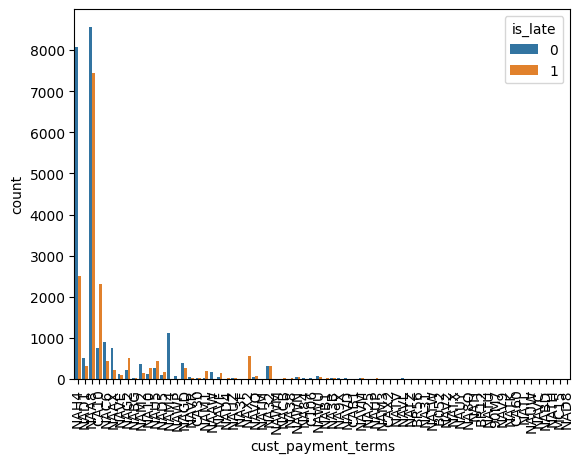

In [ ]:
sns.countplot(x='cust_payment_terms', hue='is_late', data=df)
plt.xticks(rotation=90)

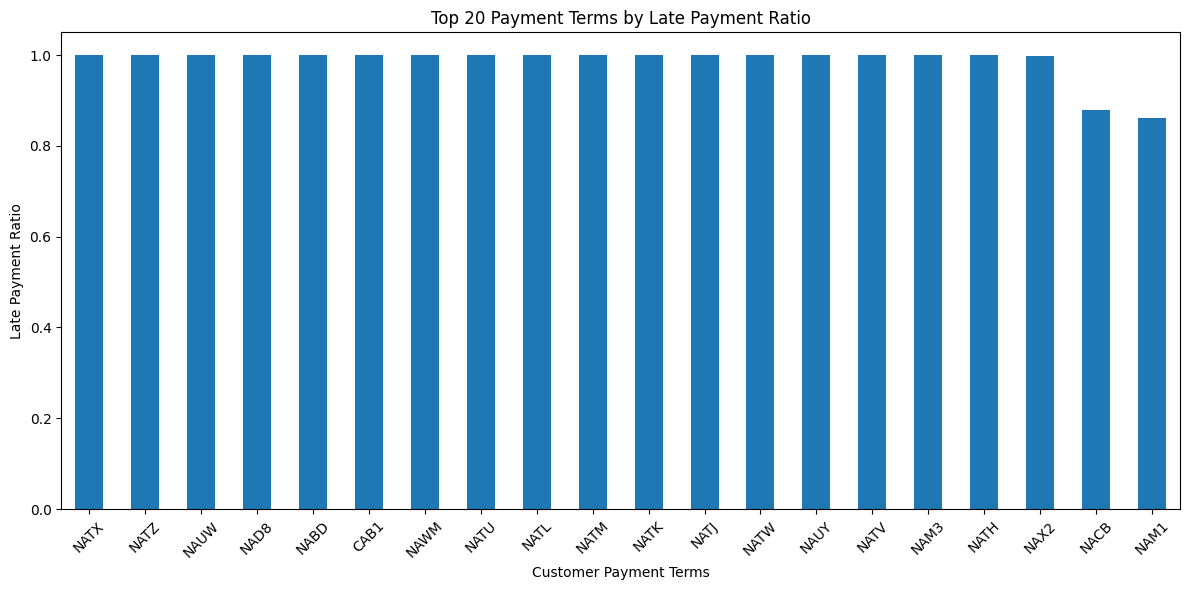

In [ ]:
# Calculate late payment ratio
late_ratio = df.groupby('cust_payment_terms')['is_late'].mean().sort_values(ascending=False)

# Plot top 20 terms with highest late ratio
late_ratio.head(20).plot(kind='bar', figsize=(12, 6), title='Top 20 Payment Terms by Late Payment Ratio')
plt.ylabel('Late Payment Ratio')
plt.xlabel('Customer Payment Terms')
plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
df.head(4)

,business_code,cust_number,clear_date,buisness_year,posting_date,document_create_date,due_in_date,document type,total_open_amount,baseline_create_date,cust_payment_terms,is_late,delay_days
0,U001,0200769623,2020-02-11,2020.0,2020-01-26,2020-01-25,2020-02-10,RV,54273.28,2020-01-26,NAH4,1,1
1,U001,0200980828,2019-08-08,2019.0,2019-07-22,2019-07-22,2019-08-11,RV,79656.60,2019-07-22,NAD1,0,-3
2,U001,0200792734,2019-12-30,2019.0,2019-09-14,2019-09-14,2019-09-29,RV,2253.86,2019-09-14,NAA8,1,92
4,U001,0200769623,2019-11-25,2019.0,2019-11-13,2019-11-13,2019-11-28,RV,33133.29,2019-11-13,NAH4,0,-3


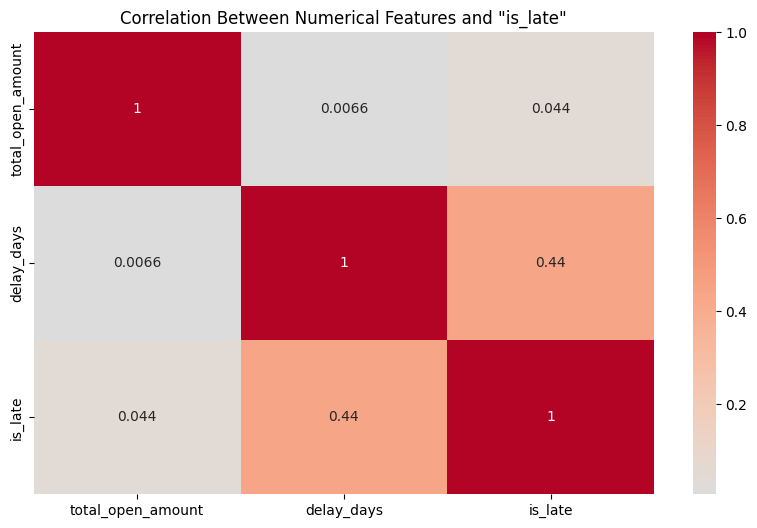

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns (adjust as needed)
numerical_cols = ['total_open_amount', 'delay_days']
corr_matrix = df[numerical_cols + ['is_late']].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numerical Features and "is_late"')
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min((k-1), (r-1)))

# Example: Correlation between 'cust_payment_terms' and 'is_late'
cramers_v(df['cust_payment_terms'], df['is_late'])
#Moderate Association

np.float64(0.38706046645964554)

Text(0.5, 1.0, 'Invoice Amount Distribution by Payment Term and Late Status')

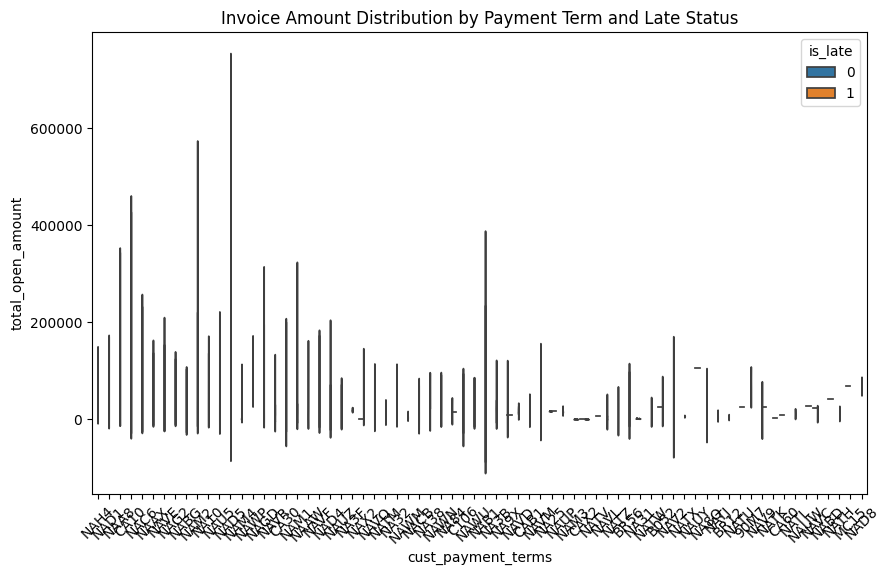

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(x='cust_payment_terms', y='total_open_amount', hue='is_late',
               data=df, split=True, inner='quartile')
plt.xticks(rotation=45)
plt.title('Invoice Amount Distribution by Payment Term and Late Status')

Text(0.5, 1.0, 'Top 10 Highest-Volume Late Payment Terms')

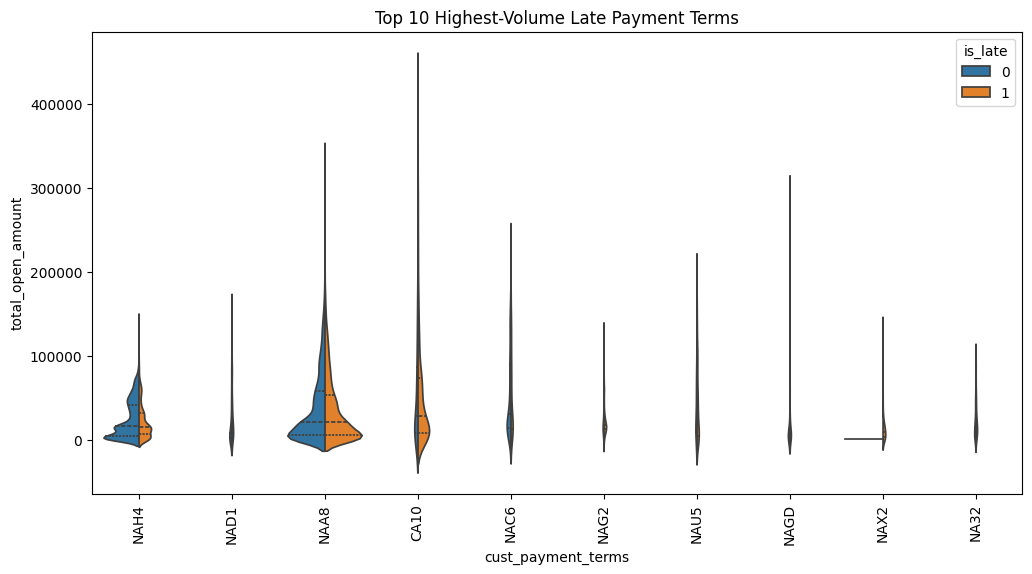

In [ ]:
# Get top 10 terms by late payment count
top_terms = df[df['is_late']==1]['cust_payment_terms'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.violinplot(x='cust_payment_terms', y='total_open_amount', hue='is_late',
               data=df[df['cust_payment_terms'].isin(top_terms)],
               split=True, inner='quartile', scale='count')  # Scale violins by sample size
plt.xticks(rotation=90)
plt.title('Top 10 Highest-Volume Late Payment Terms')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

In [ ]:
# Define features and target
X = df[['cust_payment_terms', 'cust_payment_terms', 'delay_days']]  # Add other features
y = df['is_late']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Categorical features (one-hot encode)
categorical_features = ['cust_payment_terms', 'cust_payment_terms']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Numerical features (scale)
numerical_features = ['total_open_amount', 'delay_days']
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
print("Actual columns in DataFrame:", df.columns.tolist())

Actual columns in DataFrame: ['business_code', 'cust_number', 'clear_date', 'buisness_year', 'posting_date', 'document_create_date', 'due_in_date', 'document type', 'total_open_amount', 'baseline_create_date', 'cust_payment_terms', 'is_late', 'delay_days']


In [ ]:
df

,business_code,cust_number,clear_date,buisness_year,posting_date,document_create_date,due_in_date,document type,total_open_amount,baseline_create_date,cust_payment_terms,is_late,delay_days
0,U001,0200769623,2020-02-11,2020.0,2020-01-26,2020-01-25,2020-02-10,RV,54273.28,2020-01-26,NAH4,1,1
1,U001,0200980828,2019-08-08,2019.0,2019-07-22,2019-07-22,2019-08-11,RV,79656.60,2019-07-22,NAD1,0,-3
2,U001,0200792734,2019-12-30,2019.0,2019-09-14,2019-09-14,2019-09-29,RV,2253.86,2019-09-14,NAA8,1,92
4,U001,0200769623,2019-11-25,2019.0,2019-11-13,2019-11-13,2019-11-28,RV,33133.29,2019-11-13,NAH4,0,-3
5,CA02,0140106181,2019-12-04,2019.0,2019-09-20,2019-09-20,2019-10-04,RV,22225.84,2019-09-24,CA10,1,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,U001,0200762301,2019-07-25,2019.0,2019-07-10,2019-07-09,2019-07-25,RV,84780.40,2019-07-10,NAC6,0,0
49996,U001,0200769623,2019-09-03,2019.0,2019-08-15,2019-08-14,2019-08-30,RV,6766.54,2019-08-15,NAH4,1,4
49997,U001,0200772595,2020-03-05,2020.0,2020-02-19,2020-02-18,2020-03-05,RV,6120.86,2020-02-19,NAA8,0,0
49998,U001,0200726979,2019-12-12,2019.0,2019-11-27,2019-11-26,2019-12-12,RV,63.48,2019-11-27,NAA8,0,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# --------------------------------------------------
# 1. Load and Prepare Data (SAFE VERSION)
# --------------------------------------------------
# df = pd.read_csv('your_data.csv')

# Convert dates safely
date_cols = ['clear_date', 'due_in_date', 'document_create_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Drop rows with invalid dates
df = df.dropna(subset=date_cols)

# Create target without leakage
df['is_late'] = (df['clear_date'] > df['due_in_date']).astype(int)

# --------------------------------------------------
# 2. Feature Engineering (SAFE FEATURES)
# --------------------------------------------------
# Only use knowledge available at invoice creation
df['due_duration'] = (df['due_in_date'] - df['document_create_date']).dt.days

# Select features carefully
features = [
    'business_code',
    'cust_payment_terms',
    'document type',
    'total_open_amount',
    'due_duration'
]

X = df[features]
y = df['is_late']

# --------------------------------------------------
# 3. Robust Train-Test Split
# --------------------------------------------------
# Method 1: Standard random split (use this first)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Method 2: Time-based split (alternative)
# df = df.sort_values('document_create_date')
# train_size = int(0.8 * len(df))
# X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
# y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --------------------------------------------------
# 4. Preprocessing Pipeline
# --------------------------------------------------
numeric_features = ['total_open_amount', 'due_duration']
categorical_features = ['business_code', 'cust_payment_terms', 'document type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=50  # Helps prevent overfitting
    ), categorical_features)
])

# --------------------------------------------------
# 5. Logistic Regression Model
# --------------------------------------------------
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1,  # Strong regularization
        random_state=42,
        solver='lbfgs'
    ))
])

# --------------------------------------------------
# 6. Training and Evaluation
# --------------------------------------------------
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== REALISTIC MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# --------------------------------------------------
# 7. Feature Analysis
# --------------------------------------------------
# Get feature names
cat_features = model.named_steps['preprocessor'].named_transformers_['cat']
all_features = numeric_features + list(cat_features.get_feature_names_out(categorical_features))

# Show coefficients
coef_df = pd.DataFrame({
    'feature': all_features,
    'coefficient': model.named_steps['classifier'].coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTOP PREDICTORS:")
print(coef_df.head(10))

=== REALISTIC MODEL PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.76      0.52      0.62      4647
           1       0.54      0.78      0.63      3353

    accuracy                           0.62      8000
   macro avg       0.65      0.65      0.62      8000
weighted avg       0.67      0.62      0.62      8000


ROC-AUC: 0.7054

TOP PREDICTORS:
                    feature  coefficient
21  cust_payment_terms_NAM4    -3.266633
29  cust_payment_terms_NAX2     2.562044
11  cust_payment_terms_NAAW    -1.698629
19  cust_payment_terms_NAM1     1.317404
18  cust_payment_terms_NAH4    -1.082129
12  cust_payment_terms_NAAX    -1.048942
16  cust_payment_terms_NAG2     0.986224
20  cust_payment_terms_NAM2    -0.873417
8   cust_payment_terms_NA10     0.758293
25  cust_payment_terms_NAVQ     0.711132


=== Decision Tree Performance ===
              precision    recall  f1-score   support

           0       0.79      0.43      0.56      4647
           1       0.52      0.84      0.64      3353

    accuracy                           0.60      8000
   macro avg       0.65      0.63      0.60      8000
weighted avg       0.67      0.60      0.59      8000

ROC-AUC: 0.6932


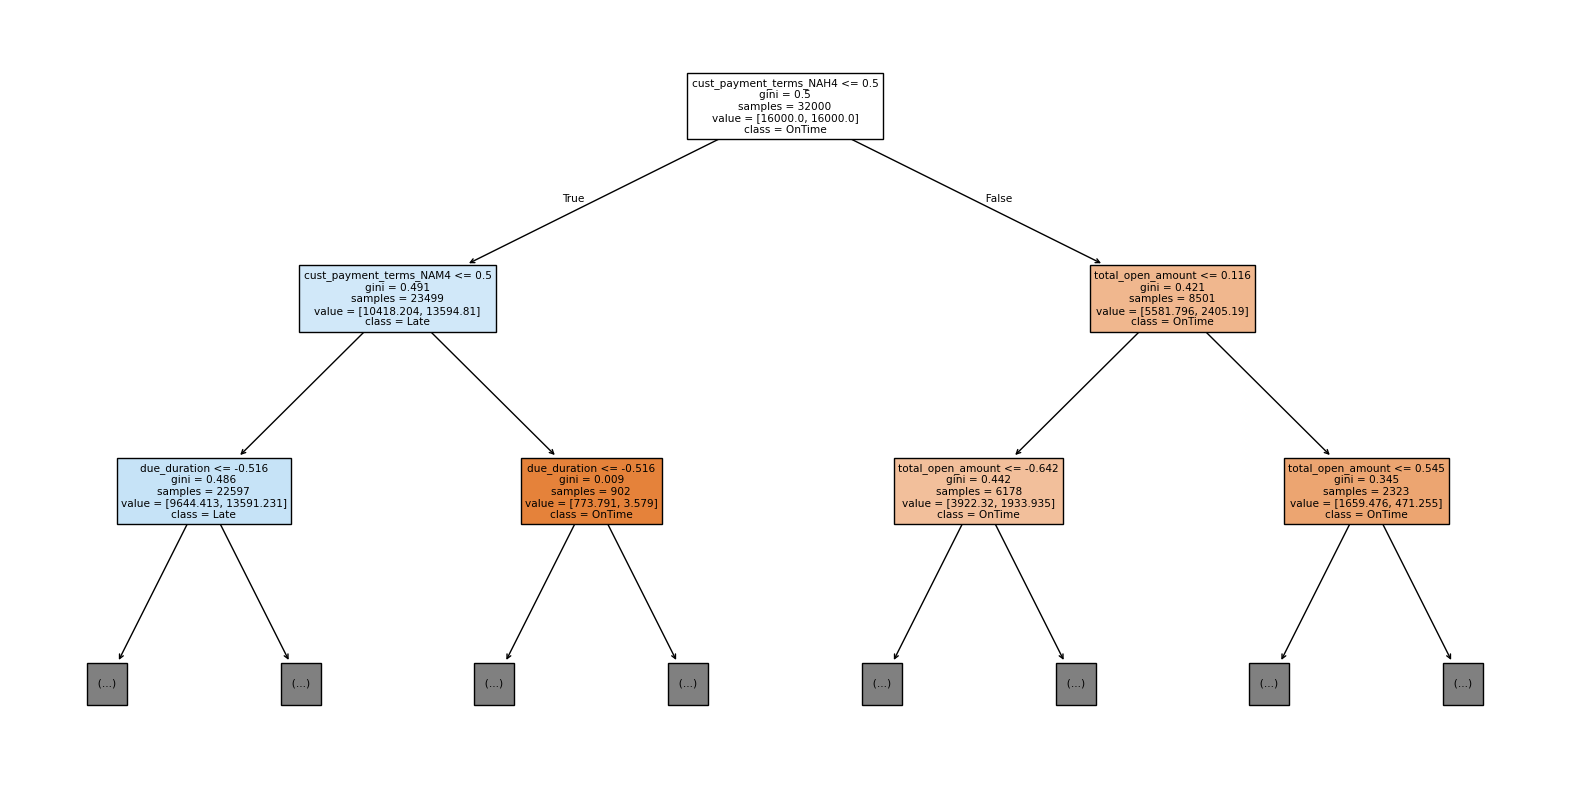

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Load and prepare data
# df = pd.read_csv('your_data.csv')

# Feature engineering
df['due_duration'] = (pd.to_datetime(df['due_in_date']) - pd.to_datetime(df['document_create_date'])).dt.days
df['is_late'] = (df['clear_date'] > df['due_in_date']).astype(int)

# Select features
X = df[['business_code', 'cust_payment_terms', 'document type',
        'total_open_amount', 'due_duration']]
y = df['is_late']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing
numeric_features = ['total_open_amount', 'due_duration']
categorical_features = ['business_code', 'cust_payment_terms', 'document type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=50),
     categorical_features)
])

# Decision Tree Model
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,               # Prevent overfitting
        min_samples_leaf=50,       # Minimum records per leaf
        class_weight='balanced',
        random_state=42
    ))
])

# Train
dt_model.fit(X_train, y_train)

# Evaluate
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree Performance ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Feature Importance
importances = dt_model.named_steps['classifier'].feature_importances_
feature_names = numeric_features + list(
    dt_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

# Visualize the tree (first 2 levels)
plt.figure(figsize=(20,10))
plot_tree(dt_model.named_steps['classifier'],
          feature_names=feature_names,
          class_names=['OnTime', 'Late'],
          filled=True, max_depth=2)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Load and prepare data
# df = pd.read_csv('your_data.csv')

# Feature engineering
df['due_duration'] = (pd.to_datetime(df['due_in_date']) - pd.to_datetime(df['document_create_date'])).dt.days
df['is_late'] = (df['clear_date'] > df['due_in_date']).astype(int)

# Select features
X = df[['business_code', 'cust_payment_terms', 'document type',
        'total_open_amount', 'due_duration']]
y = df['is_late']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing
numeric_features = ['total_open_amount', 'due_duration']
categorical_features = ['business_code', 'cust_payment_terms', 'document type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'),
     categorical_features)
])

# Model Definitions
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=sum(y==0)/sum(y==1),  # Handle imbalance
        eval_metric='auc',
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=150,
        learning_rate=0.5,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
}

# Training and Evaluation
results = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'classification_report': classification_report(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'model': pipeline
    }

    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Compare all models
print("\n=== Model Comparison ===")
for name, result in results.items():
    print(f"\n{name}:")
    print(f"ROC-AUC: {result['roc_auc']:.4f}")
    print(classification_report(y_test, result['model'].predict(X_test)))

# Feature Importance (Example for XGBoost)
xgb_model = results['XGBoost']['model']
importances = xgb_model.named_steps['classifier'].feature_importances_
feature_names = numeric_features + list(
    xgb_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)


=== Training XGBoost ===

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.75      0.59      0.66      4647
           1       0.56      0.73      0.63      3353

    accuracy                           0.65      8000
   macro avg       0.66      0.66      0.65      8000
weighted avg       0.67      0.65      0.65      8000

ROC-AUC: 0.7334

=== Training AdaBoost ===

AdaBoost Performance:
              precision    recall  f1-score   support

           0       0.64      0.94      0.76      4647
           1       0.75      0.26      0.39      3353

    accuracy                           0.65      8000
   macro avg       0.69      0.60      0.57      8000
weighted avg       0.68      0.65      0.60      8000

ROC-AUC: 0.7036

=== Training Random Forest ===

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.76      0.54      0.63      4647
           1       0.55      0.76      0.64    

,Feature,Importance
47,cust_payment_terms_NAM4,0.170441
43,cust_payment_terms_NAH4,0.148957
3,business_code_U001,0.085514
45,cust_payment_terms_NAM2,0.077087
76,cust_payment_terms_NAX2,0.046432
30,cust_payment_terms_NAAW,0.035947
31,cust_payment_terms_NAAX,0.035436
58,cust_payment_terms_NAU5,0.035435
13,cust_payment_terms_CA10,0.034427
41,cust_payment_terms_NAG2,0.033160


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load Data
# df = pd.read_csv('your_data.csv')

# 2. SAFE Feature Engineering
df['due_duration'] = (pd.to_datetime(df['due_in_date']) -
                     pd.to_datetime(df['document_create_date'])).dt.days
df['is_late'] = (pd.to_datetime(df['clear_date']) >
                pd.to_datetime(df['due_in_date'])).astype(int)

# 3. Remove High-Cardinality Features
X = df[['business_code', 'cust_payment_terms', 'document type',
        'total_open_amount', 'due_duration']]
y = df['is_late']

# 4. Time-Based Split
df = df.sort_values('document_create_date')
train_size = int(0.8 * len(df))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 5. Preprocessing
numeric_features = ['total_open_amount', 'due_duration']
categorical_features = ['business_code', 'cust_payment_terms', 'document type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=50),
     categorical_features)
])

# 6. Conservative Model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=50,
        class_weight='balanced_subsample',
        random_state=42
    ))
])

# 7. Training & Evaluation
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== REALISTIC PERFORMANCE ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

=== REALISTIC PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.75      0.51      0.61      4621
           1       0.53      0.76      0.63      3379

    accuracy                           0.62      8000
   macro avg       0.64      0.64      0.62      8000
weighted avg       0.66      0.62      0.62      8000

ROC-AUC: 0.6992


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # Important: Use imblearn's Pipeline
from xgboost import XGBClassifier
from collections import Counter

# 1. Load and prepare data
# df = pd.read_csv('your_data.csv')

# Feature engineering
df['due_duration'] = (pd.to_datetime(df['due_in_date']) - pd.to_datetime(df['document_create_date'])).dt.days
df['is_late'] = (df['clear_date'] > df['due_in_date']).astype(int)

# 2. Select features
X = df[['business_code', 'cust_payment_terms', 'total_open_amount', 'due_duration']]
y = df['is_late']

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Define preprocessing
categorical_features = ['business_code', 'cust_payment_terms']
numeric_features = ['total_open_amount', 'due_duration']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# 5. Configure SMOTE properly
print("Original class distribution:", Counter(y_train))

# Calculate safe sampling strategy
majority_count = sum(y_train == 0)
minority_count = sum(y_train == 1)
target_minority = int(0.8 * majority_count)  # Target 80% of majority class size

# Ensure we're not reducing the minority class
if minority_count > target_minority:
    target_minority = minority_count

# 6. Create complete pipeline
smote_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(
        sampling_strategy={1: target_minority},
        random_state=42,
        k_neighbors=min(5, minority_count-1)
    )),
    ('classifier', XGBClassifier(
        scale_pos_weight=majority_count/minority_count,
        eval_metric='auc',
        random_state=42
    ))
])

# 7. Train and evaluate
smote_pipeline.fit(X_train, y_train)

# Check new class distribution
X_resampled, y_resampled = smote_pipeline.named_steps['smote'].fit_resample(
    smote_pipeline.named_steps['preprocessor'].transform(X_train),
    y_train
)
print("Resampled class distribution:", Counter(y_resampled))

# Evaluation
y_pred = smote_pipeline.predict(X_test)
y_proba = smote_pipeline.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Original class distribution: Counter({0: 18589, 1: 13411})
Resampled class distribution: Counter({0: 18589, 1: 14871})

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.56      0.64      4647
           1       0.55      0.75      0.64      3353

    accuracy                           0.64      8000
   macro avg       0.65      0.65      0.64      8000
weighted avg       0.67      0.64      0.64      8000

ROC-AUC: 0.7273


In [ ]:
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'scale_pos_weight': [1, sum(y==0)/sum(y==1)]
}

xgb = XGBClassifier(
    n_estimators=300,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42
)

# Time-based cross-validation
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(xgb, param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Ensure your df has these columns:
# ['business_code', 'cust_number', 'clear_date', 'buisness_year',
#  'posting_date', 'document_create_date', 'due_in_date',
#  'document_type', 'total_open_amount', 'baseline_create_date',
#  'cust_payment_terms', 'is_late']

# Fix dates
df['document_create_date'] = pd.to_datetime(df['document_create_date'])
df['due_in_date'] = pd.to_datetime(df['due_in_date'])

# Calculate only safe features
df['due_duration'] = (df['due_in_date'] - df['document_create_date']).dt.days
df['creation_day_of_week'] = df['document_create_date'].dt.dayofweek
df['is_weekend_create'] = (df['creation_day_of_week'] >= 5).astype(int)



# New Section

In [ ]:
df

,business_code,cust_number,clear_date,buisness_year,posting_date,document_create_date,due_in_date,document type,total_open_amount,baseline_create_date,cust_payment_terms,is_late,delay_days,due_duration,creation_day_of_week,is_weekend_create
10052,U013,0140103335,2019-01-23,2019.0,2018-12-30,2018-12-26,2019-01-29,RV,13760.55,2018-12-30,NAVE,0,-6,34,2,0
20128,U013,0100009932,2019-02-28,2019.0,2018-12-30,2018-12-28,2019-01-29,RV,28225.48,2018-12-30,NAVE,1,30,32,4,0
2392,U001,0200769623,2019-01-09,2019.0,2018-12-30,2018-12-29,2019-01-14,RV,47642.00,2018-12-30,NAH4,0,-5,16,5,1
29464,U001,0200706844,2019-01-15,2019.0,2018-12-30,2018-12-29,2019-01-14,RV,57640.90,2018-12-30,NAA8,1,1,16,5,1
29571,U001,0200726979,2019-01-15,2019.0,2018-12-30,2018-12-29,2019-01-14,RV,79.88,2018-12-30,NAA8,1,1,16,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42248,U001,0200707822,2020-03-12,2020.0,2020-02-26,2020-02-27,2020-03-12,RV,90643.88,2020-02-26,NAA8,0,0,14,3,0
4700,U001,0200771157,2020-03-12,2020.0,2020-02-26,2020-02-27,2020-03-12,RV,14880.14,2020-02-26,NAA8,0,0,14,3,0
17190,U001,0200769623,2020-03-10,2020.0,2020-02-26,2020-02-27,2020-03-12,RV,5126.33,2020-02-26,NAH4,0,-2,14,3,0
49046,U001,0200692711,2020-03-04,2020.0,2020-02-26,2020-02-27,2020-03-07,RV,56296.00,2020-02-26,NA10,0,-3,9,3,0


In [ ]:
feature_cols = [
    'buisness_year',
    'posting_date',
    'document_create_date',
    'due_in_date',
    'document type',
    'total_open_amount',
    'baseline_create_date',
    'cust_payment_terms',
    'due_duration',
    'creation_day_of_week',
    'is_weekend_create'
]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer


In [ ]:
# Load your DataFrame df here

# Only keep the needed columns
X = df[feature_cols]
y = df['is_late']

# Ensure dates are datetime
date_cols = ['posting_date', 'document_create_date', 'due_in_date', 'baseline_create_date']
X[date_cols] = X[date_cols].apply(pd.to_datetime)

# Create month, day, etc., features from dates (if needed—optional)
X['posting_day'] = X['posting_date'].dt.day
X['posting_month'] = X['posting_date'].dt.month
X['create_day'] = X['document_create_date'].dt.day
X['create_month'] = X['document_create_date'].dt.month
# ... repeat for other dates as needed

# Update feature_cols if you add these
feature_cols = list(X.columns)


In [ ]:
# Split into numeric and categorical
numeric_cols = ['buisness_year', 'total_open_amount', 'due_duration', 'creation_day_of_week']
categorical_cols = ['cust_payment_terms', 'document type']
# Add others as needed (e.g., 'business_code', 'posting_day', etc.)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # For time-based split
)


In [ ]:
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', use_label_encoder=False))
])
ada = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier())
])
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

xgb.fit(X_train, y_train)
ada.fit(X_train, y_train)
rf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['buisness_year',
                                                   'total_open_amount',
                                                   'due_duration',
                                                   'creation_day_of_week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cust_payment_terms',
                                                   'document type'])])),
                ('classifier', RandomForestClassifier())])

In [ ]:
# Voting
ensemble_vote = VotingClassifier(
    estimators=[('xgb', xgb), ('ada', ada), ('rf', rf)],
    voting='soft'
)
ensemble_vote.fit(X_train, y_train)

# Stacking
stack = StackingClassifier(
    estimators=[('xgb', xgb), ('ada', ada), ('rf', rf)],
    final_estimator=LogisticRegression(),
    cv=5
)
stack.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('xgb',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['buisness_year',
                                                                                   'total_open_amount',
                                                                                   'due_duration',
                                                                                   'creation_day_of_week']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequ...
                                                                                                  ('scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['buisness_year',
                                                                                   'total_open_amount',
                                                                                   'due_duration',
                                                                                   'creation_day_of_week']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('onehot',
                                                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                                                  ['cust_payment_terms',
                                                                                   'document '
                                                                                   'type'])])),
                                                ('classifier',
                                                 RandomForestClassifier())]))],
                   final_estimator=LogisticRegression())

In [ ]:
def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print(classification_report(y_true, y_pred))
    print("=" * 40)

print("=== XGBoost ===")
evaluate_model(xgb, X_test, y_test)

print("=== AdaBoost ===")
evaluate_model(ada, X_test, y_test)

print("=== Random Forest ===")
evaluate_model(rf, X_test, y_test)

print("=== Voting Ensemble (Soft) ===")
evaluate_model(ensemble_vote, X_test, y_test)

print("=== Stacking Ensemble (Logistic Meta) ===")
evaluate_model(stack, X_test, y_test)


=== XGBoost ===
Accuracy: 0.723
ROC-AUC: 0.7727225695263558
              precision    recall  f1-score   support

           0       0.73      0.85      0.79      4860
           1       0.70      0.52      0.60      3140

    accuracy                           0.72      8000
   macro avg       0.72      0.69      0.69      8000
weighted avg       0.72      0.72      0.71      8000

=== AdaBoost ===
Accuracy: 0.65825
ROC-AUC: 0.7039943579460565
              precision    recall  f1-score   support

           0       0.65      0.94      0.77      4860
           1       0.70      0.22      0.34      3140

    accuracy                           0.66      8000
   macro avg       0.68      0.58      0.55      8000
weighted avg       0.67      0.66      0.60      8000

=== Random Forest ===
Accuracy: 0.658625
ROC-AUC: 0.719749023616681
              precision    recall  f1-score   support

           0       0.72      0.71      0.72      4860
           1       0.56      0.58      0.57   

In [ ]:
y_proba = stack.predict_proba(X_test)[:, 1]  # Late class probabilities
for threshold in [0.3, 0.4, 0.5, 0.6]:  # Experiment
    y_pred_new = (y_proba > threshold).astype(int)
    print("\nThreshold:", threshold)
    print(classification_report(y_test, y_pred_new))



Threshold: 0.3
              precision    recall  f1-score   support

           0       0.81      0.54      0.65      4860
           1       0.53      0.81      0.64      3140

    accuracy                           0.65      8000
   macro avg       0.67      0.68      0.65      8000
weighted avg       0.70      0.65      0.65      8000


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.77      0.74      0.76      4860
           1       0.62      0.66      0.64      3140

    accuracy                           0.71      8000
   macro avg       0.70      0.70      0.70      8000
weighted avg       0.71      0.71      0.71      8000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.74      0.85      0.79      4860
           1       0.69      0.53      0.60      3140

    accuracy                           0.72      8000
   macro avg       0.71      0.69      0.69      8000
weighted avg       0.72   

In [ ]:
min_val = df['due_duration'].min()
if min_val < 0:
    df['due_duration'] = df['due_duration'] - min_val

In [ ]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

# Select features available at invoice creation
feature_cols = [
    'buisness_year', 'due_duration', 'creation_day_of_week', 'is_weekend_create',
    'total_open_amount', 'business_code', 'cust_payment_terms', 'document type'
]
X = df[feature_cols]
y = df['is_late']

# Label encode categorical features
cat_cols = ['business_code', 'cust_payment_terms', 'document type']
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Ensure no negative values (chi2 requires non-negative)
for col in X.columns:
    if any(X[col] < 0):
        raise ValueError(f"Negative values in {col}—cannot use chi2.")

# Apply chi2 test
chi2_scores, p_values = chi2(X, y)

# Create a results table
chi2_results = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi2_scores,
    'p_value': p_values
}).sort_values('Chi2_Score', ascending=False)

print(chi2_results)


                Feature    Chi2_Score       p_value
4     total_open_amount  3.741908e+06  0.000000e+00
6    cust_payment_terms  2.987055e+03  0.000000e+00
5         business_code  4.693836e+01  7.325462e-12
2  creation_day_of_week  3.154631e+01  1.947397e-08
3     is_weekend_create  1.417016e+01  1.669980e-04
1          due_duration  1.081889e+01  1.004700e-03
7         document type  8.316392e+00  3.928888e-03
0         buisness_year  6.941164e-05  9.933526e-01


In [ ]:
# Assume your DataFrame is named df
feature_cols = ['total_open_amount', 'cust_payment_terms']
X = df[feature_cols]
y = df['is_late']


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Identify feature types (all features except target)
categorical_cols = ['cust_payment_terms']
numeric_cols = ['total_open_amount']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute any missing values
    ('scaler', StandardScaler())  # Scale numeric features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute any missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categories
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # For time-based split
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
model_ada = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(random_state=42))
])
# Only include XGBoost if installed on your system
try:
    model_xgb = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(eval_metric='logloss', use_label_encoder=False))
    ])
except NameError:
    pass

model_rf.fit(X_train, y_train)
model_ada.fit(X_train, y_train)
try:
    model_xgb.fit(X_train, y_train)
except NameError:
    print("XGBoost not installed—skipping.")


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))
    print("=" * 40)

print("=== Random Forest ===")
evaluate_model(model_rf, X_test, y_test)

print("=== AdaBoost ===")
evaluate_model(model_ada, X_test, y_test)

try:
    print("=== XGBoost ===")
    evaluate_model(model_xgb, X_test, y_test)
except NameError:
    pass


=== Random Forest ===
Accuracy: 0.612625
ROC-AUC: 0.6655031650546512
              precision    recall  f1-score   support

           0       0.69      0.66      0.68      4860
           1       0.51      0.53      0.52      3140

    accuracy                           0.61      8000
   macro avg       0.60      0.60      0.60      8000
weighted avg       0.62      0.61      0.61      8000

=== AdaBoost ===
Accuracy: 0.650375
ROC-AUC: 0.6813318785877173
              precision    recall  f1-score   support

           0       0.64      0.97      0.77      4860
           1       0.76      0.16      0.27      3140

    accuracy                           0.65      8000
   macro avg       0.70      0.56      0.52      8000
weighted avg       0.69      0.65      0.57      8000

=== XGBoost ===
Accuracy: 0.66325
ROC-AUC: 0.7092081138109092
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      4860
           1       0.61      0.40      0.4

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Example feature list (replace df with your actual DataFrame)
feature_cols = [
    'total_open_amount',
    'cust_payment_terms',
    'business_code',
    'creation_day_of_week',
    'is_weekend_create',
    'due_duration',
    'document type'
]
X = df[feature_cols]
y = df['is_late']

# For time-based split (recommended for real data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # Use shuffle=False for time series
)

numeric_cols = ['total_open_amount', 'creation_day_of_week', 'is_weekend_create', 'due_duration']
categorical_cols = ['cust_payment_terms', 'business_code', 'document type']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [ ]:
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [20, 50],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5]
}


In [ ]:
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}


In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))



Test Accuracy: 0.715125
Test ROC-AUC: 0.7590389832507667
              precision    recall  f1-score   support

           0       0.71      0.91      0.79      4860
           1       0.74      0.42      0.54      3140

    accuracy                           0.72      8000
   macro avg       0.72      0.66      0.67      8000
weighted avg       0.72      0.72      0.69      8000



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.utils import resample

# Your feature set (from chi-square results)
feature_cols = [
    'total_open_amount',
    'cust_payment_terms',
    'business_code',
    'creation_day_of_week',
    'is_weekend_create',
    'due_duration',
    'document type'
]
X = df[feature_cols]
y = df['is_late']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [ ]:
numeric_cols = ['total_open_amount', 'creation_day_of_week', 'is_weekend_create', 'due_duration']
categorical_cols = ['cust_payment_terms', 'business_code', 'document type']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Undersample majority class for balanced training
undersampler = RandomUnderSampler(random_state=42)

# Pipeline for XGBoost
xgb_pipe = imbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', undersampler),
    ('classifier', XGBClassifier(eval_metric='logloss'))
])

# Pipeline for Random Forest
rf_pipe = imbPipeline([
    ('preprocessor', preprocessor),
    ('sampler', undersampler),
    ('classifier', RandomForestClassifier())
])

# Fit both
xgb_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

# Ensemble the two
ensemble = VotingClassifier(
    estimators=[('xgb', xgb_pipe.named_steps['classifier']),
                ('rf', rf_pipe.named_steps['classifier'])],
    voting='soft'
)

# But to include preprocessing, rebuild with full fitted transformers
from sklearn.base import clone
preprocessor_fitted = clone(preprocessor).fit(X_train)
X_train_trans = preprocessor_fitted.transform(X_train)
X_test_trans = preprocessor_fitted.transform(X_test)

# Undersample majority class only for the transformed data
X_train_trans_under, y_train_under = undersampler.fit_resample(X_train_trans, y_train)

# Train XGBoost on balanced data
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train_trans_under, y_train_under)

# Train Random Forest on balanced data
rf = RandomForestClassifier()
rf.fit(X_train_trans_under, y_train_under)

# Ensemble
ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    voting='soft'
)
ensemble.fit(X_train_trans_under, y_train_under)

# Evaluate on the original test set (no undersampling)
y_pred = ensemble.predict(X_test_trans)
y_proba = ensemble.predict_proba(X_test_trans)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


Accuracy: 0.676875
ROC-AUC: 0.7509541361956436
              precision    recall  f1-score   support

           0       0.75      0.70      0.72      4860
           1       0.58      0.65      0.61      3140

    accuracy                           0.68      8000
   macro avg       0.67      0.67      0.67      8000
weighted avg       0.68      0.68      0.68      8000

